# Comparing VAE vs $\beta$-VAE vs CVAE generative neual network models on MNIST dataset

In this notebook I compare several variational autoencoder models implemented with a custom class ```VAE``` developed the [vae.py](vae.py) file. The comparisions include:
* Data reconstruction
* Latent space visualization
* Image generation
* Image interpolation

In [ ]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, random_split

from torch.nn import (Module, Sequential, Linear, Conv2d, ConvTranspose2d,
                      ReLU, Tanh, Sigmoid, GELU, LeakyReLU, Softplus)

from itertools import chain

from umap import UMAP

from vae import VAE # custom class on vae.py file

In [2]:
device = "cuda"

## MNIST Dataset

PyTorch provides a collection of ready-to-use datasets through its ```torchvision.datasets``` module, including the MNIST dataset. Hence, I do not include the dataset in the project, but the follwoing script creates a dir [data/](data/) where PyTorch will store it.

In [ ]:
!mkdir data

In [ ]:
full_train_dataset = MNIST(
    root='./data',
    train=True,
    transform=ToTensor(),
    download=True
)
test_dataset = MNIST(
    root='./data',
    train=False,
    transform=ToTensor(), 
    download=True
)

train_size = int(0.8 * len(full_train_dataset)) 
val_size = len(full_train_dataset) - train_size 
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

In PyTorch, the ```DataLoader``` class wraps a dataset and provides efficient mini-batch loading, optional shuffling, and customizable batch collation, enabling automatic batching, parallel data loading, and memory pinning for GPU training.

In [4]:
def vae_collate(batch):
    X, _ = zip(*batch)
    X = torch.stack(X)
    return X.reshape(X.size(0), -1).to(device)

def cvae_collate(batch):
    X, y = zip(*batch)
    X = torch.stack(X).reshape(len(X), -1).to(device)
    y = torch.tensor(y, device=device)
    return X, y


In [ ]:
BATCH_SIZE = 128

vae_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=vae_collate
)
vae_val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=vae_collate
)
vae_test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=vae_collate
)

cvae_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=cvae_collate
)
cvae_val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=cvae_collate
)
cvae_test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=cvae_collate
)

We can see an example of the dataset as follows.

3


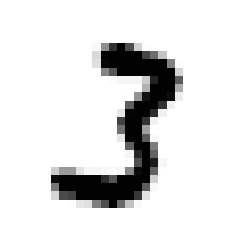

In [6]:
img, label = full_train_dataset.__getitem__(np.random.randint(0,len(full_train_dataset)))
fig,ax = plt.subplots(1,1,figsize=(3,3))
print(label)
ax.imshow(img[0],cmap="Greys")
ax.yaxis.set_inverted(True)
ax.axis("off")
plt.show()

## Model Implementation & Training

By instancing our custom ```VAE``` class with the propper parameters, we can structure each instance as a VAE, $\beta$-VAE or conditional-VAE. For this comparision and in the sake of simplicity, I used a fully-connected approach with no more than 3 layer Multi-Layer Perceptrons for the structure of the neural networks.

#### Variational Autoencoder (VAE)

In [9]:
vae = VAE(
    encoder = Sequential(
        Linear(784,350),
        ReLU(),
        Linear(350,150),
        ReLU()
    ),
    mu = Sequential(
        Linear(150,40),
        ReLU(),
        Linear(40,40)
    ),
    logvar = Sequential(
        Linear(150,40),
        ReLU(),
        Linear(40,40)
    ),
    decoder = Sequential(
        Linear(40,150),
        ReLU(),
        Linear(150,350),
        ReLU(),
        Linear(350,784),
        Sigmoid()
    ),
    alpha=0.05,
    latent_dims=40
).cuda()

Training:   0%|          | 0/5 [00:00<?, ?it/s]

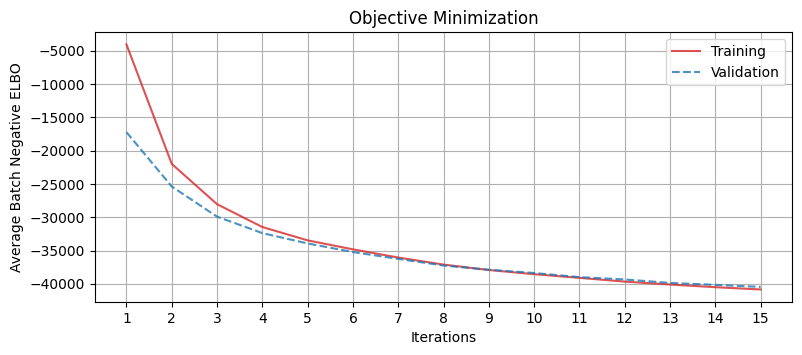

In [ ]:
vae.fit(
    optim=torch.optim.Adam(vae.parameters(),5e-4),
    train_loader=vae_train_loader,
    val_loader=vae_val_loader,
    epochs=20,
    reset_history=False
)
vae.plot_optim()
plt.show()

#### $\beta$-Variational Autoencoder ($\beta$-VAE)

In [12]:
beta_vae = VAE(
    encoder = Sequential(
        Linear(784,350),
        ReLU(),
        Linear(350,150),
        ReLU()
    ),
    mu = Sequential(
        Linear(150,40),
        ReLU(),
        Linear(40,40)
    ),
    logvar = Sequential(
        Linear(150,40),
        ReLU(),
        Linear(40,40)
    ),
    decoder = Sequential(
        Linear(40,150),
        ReLU(),
        Linear(150,350),
        ReLU(),
        Linear(350,784),
        Sigmoid()
    ),
    alpha=0.05,
    beta=2,
    latent_dims=40
).cuda()

Training:   0%|          | 0/10 [00:00<?, ?it/s]

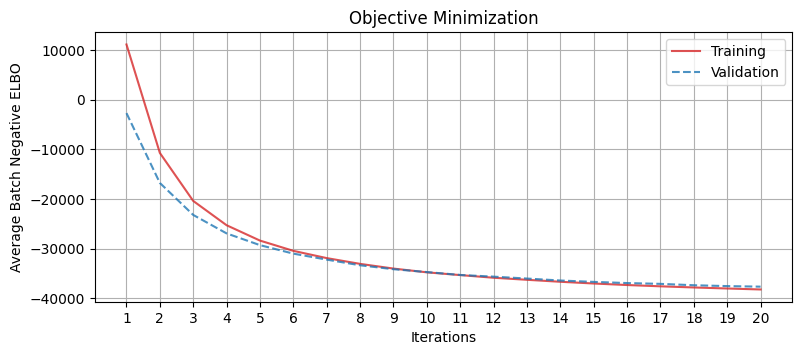

In [ ]:
beta_vae.fit(
    optim=torch.optim.Adam(beta_vae.parameters(),5e-4),
    train_loader=vae_train_loader,
    val_loader=vae_val_loader,
    epochs=20,
    reset_history=False)
beta_vae.plot_optim()
plt.show()

#### Conditional Variational Autoencoder (CVAE)

In [14]:
cond_vae = VAE(
    encoder = Sequential(
        Linear(784+10,350),
        ReLU(),
        Linear(350,150),
        ReLU()
    ),
    mu = Sequential(
        Linear(150,40),
        ReLU(),
        Linear(40,40)
    ),
    logvar = Sequential(
        Linear(150,40),
        ReLU(),
        Linear(40,40)
    ),
    decoder = Sequential(
        Linear(40+10,150),
        ReLU(),
        Linear(150,350),
        ReLU(),
        Linear(350,784),
        Sigmoid()
    ),
    alpha=0.05,
    latent_dims=40,
    conditional=True,
    categorical_conditioned=True,
    one_hot_encode=True,
    num_classes=10
).cuda()

Training: 0it [00:00, ?it/s]

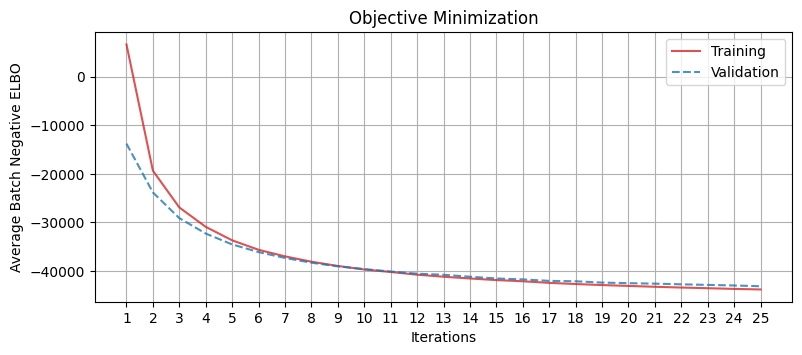

In [ ]:
cond_vae.fit(
    optim=torch.optim.Adam(cond_vae.parameters(),5e-4),
    train_loader=cvae_train_loader,
    val_loader=cvae_val_loader,
    epochs=20,
    reset_history=False
)
cond_vae.plot_optim()
plt.show()

## Model Comparision

### Reconstruction

We call a **reconstruction** as the process of encoding a value in the original space and then decoding the result from the latent space. By doing so we can direcly compare the *reconstructed* object with the original one (the input). 

$$\text{Reconstruction}(x) = \left(\text{decoder}\circ\text{encoder}\right)(x)$$

In order to test the reconstruction performance, lets create a funtion to get several test samples and reconstruct them using multiple ``VAE`` models.

In [ ]:
def random_test(models: list[VAE], n_samples:int, model_names:list[str]=None, device="cpu", figsize=None):
    """
    Display original test samples and their reconstructions from multiple VAE models.
    """
    n_models = len(models)
    if model_names is None:
        model_names = [""] * n_models

    if figsize is None:
        figsize=(n_samples*2, (n_models+1)*2)
    fig, axes = plt.subplots(n_models + 1, n_samples, figsize=figsize)

    if n_samples == 1:
        axes = axes[:, None] 

    with torch.no_grad():
        for j in range(n_samples):
            img, label = test_dataset.__getitem__(np.random.randint(0, len(test_dataset)))
            x = img.reshape(-1).to(device)
            y = torch.tensor(label, device=device)

            axes[0, j].imshow(img[0], cmap="Greys")
            axes[0, j].set_xticks([])
            axes[0, j].set_yticks([])
            axes[0, j].spines[:].set_visible(False)  # remove borders
            if j == 0:
                axes[0, j].set_ylabel("Original", rotation=90, fontsize=10, va="center")

            for i, (model, name) in enumerate(zip(models, model_names), start=1):
                x_recon, _, _ = model(x, y)
                axes[i, j].imshow(x_recon.cpu().reshape(28, 28), cmap="Greys")
                axes[i, j].set_xticks([])
                axes[i, j].set_yticks([])
                axes[i, j].spines[:].set_visible(False)  # remove borders
                if j == 0:
                    axes[i, j].set_ylabel(name, rotation=90, fontsize=10, va="center")

    plt.tight_layout()
    plt.show()


We can see in the next cell that the three models propperly learned how to reconstruct the data. The **Original** row represents a random sample of 10 elements in the TEST dataset, and the rows below represent the corresponding model reconstruction.

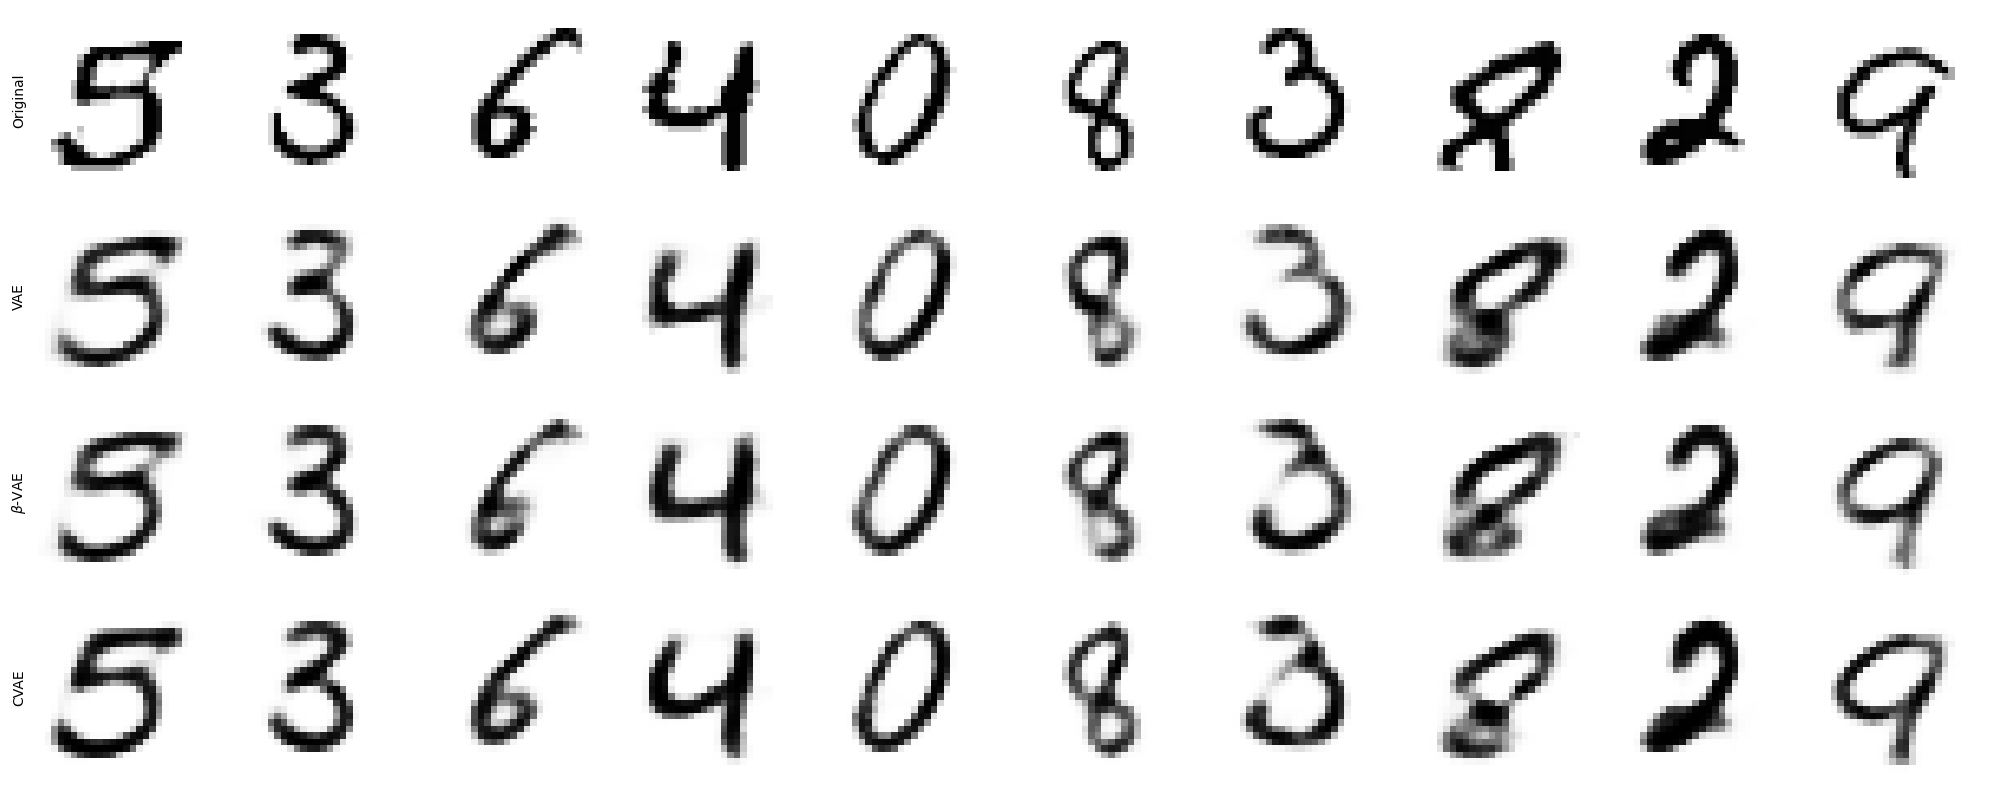

In [42]:
random_test(
    models=[vae,beta_vae,cond_vae],
    n_samples=10,
    model_names=["VAE",r"$\beta$-VAE","CVAE"],
    device=device
)

### Latent Space Structure Visualization

UMAP (Uniform Manifold Approximation and Projection) is a modern nonlinear dimensionality reduction technique that preserves both local and global structure of high-dimensional data. It is widely used for visualization and representation learning due to its strong theoretical foundation in manifold learning and its computational efficiency.

As this is a class-based dataset, we expect that the models learn a low dimensional representation of the numbers and hence, when properly visualized, similar numbers must tend to be mapped to similar regions of the latent space.

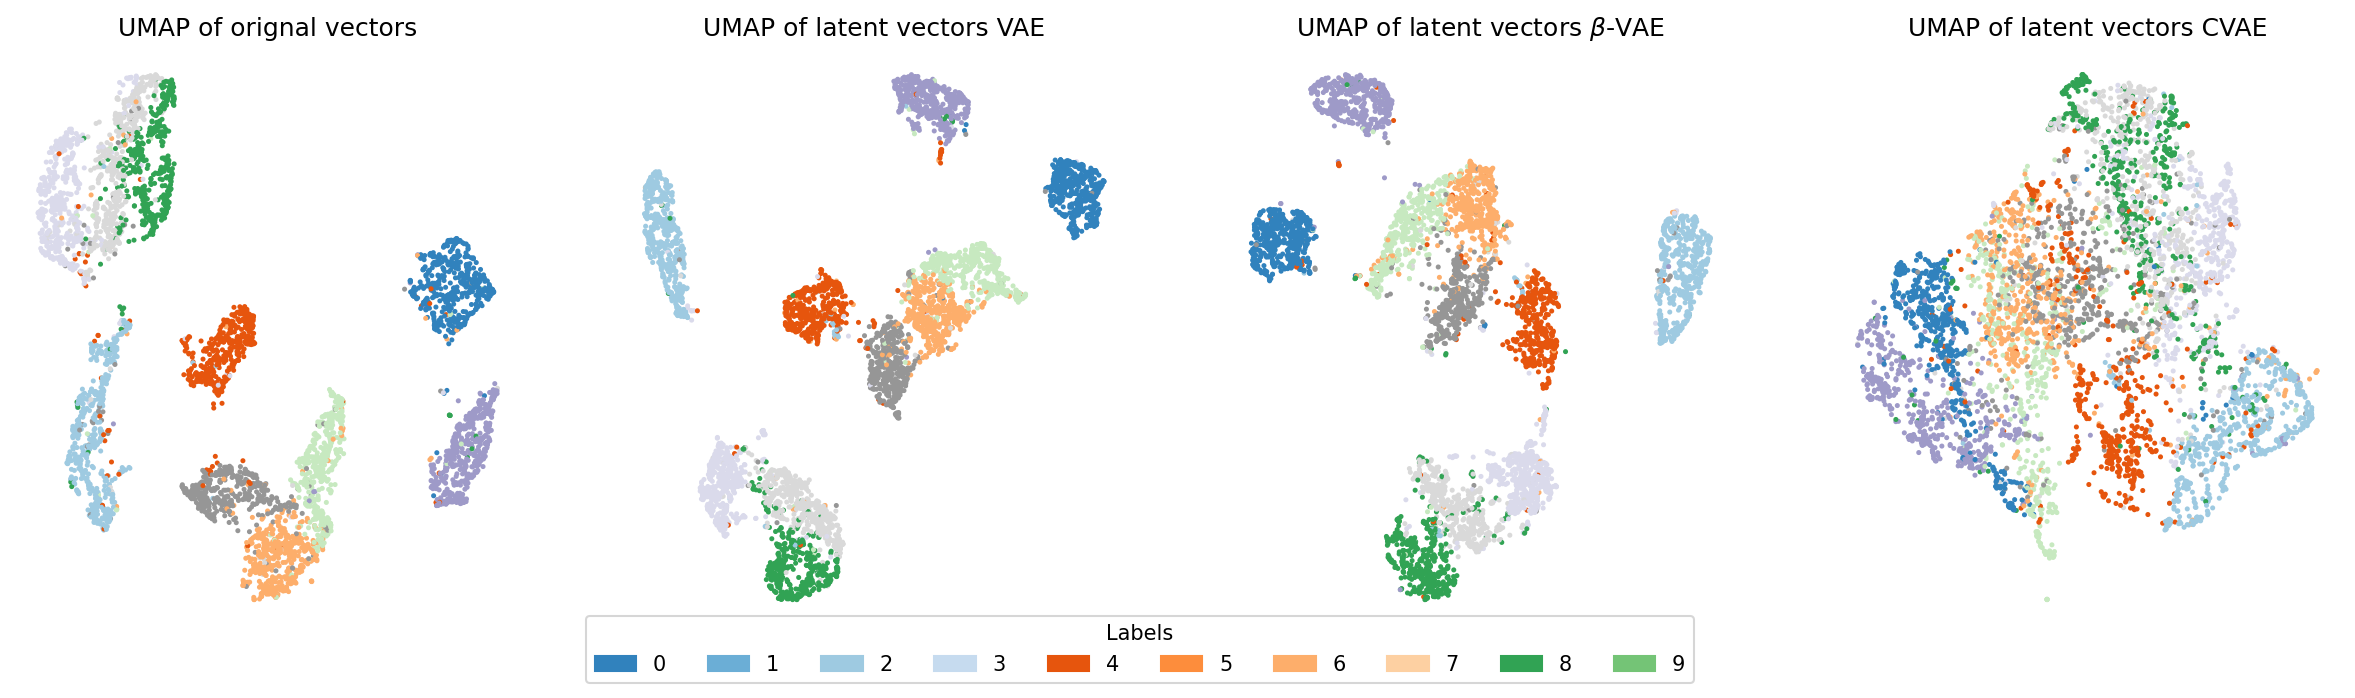

In [ ]:
sample_size = 5000
models = [vae,beta_vae,cond_vae]
model_names = ["VAE",r"$\beta$-VAE","CVAE"]

indices = np.random.choice(np.arange(len(train_dataset)), sample_size)
samples = [train_dataset[i] for i in indices]

data = torch.stack([x[0] for x, _ in samples]).reshape(-1,28*28)
labels = torch.tensor([y for _, y in samples], device=device)
labels_ = labels.cpu().numpy().reshape(-1)
    
umap_original = UMAP(
    n_neighbors=10,
    n_components=2,
    metric="euclidean"
).fit_transform(data)

fig,ax = plt.subplots(1,4,figsize=((len(models)+1)*5,5), dpi=150)
ax[0].set_title("UMAP of orignal vectors")
ax[0].scatter(
    *umap_original.T,
    c=labels_,
    cmap="tab20c",
    marker=".",
    s=8
)
ax[0].axis("off")

with torch.no_grad():
    for j,model in enumerate(models):
        latent_data, _ = model.encode(data.to(device),labels)
        latent_data = latent_data.cpu().numpy()

        umap_latent = UMAP(
            n_neighbors=10,
            n_components=2,
            metric="euclidean"
        ).fit_transform(latent_data)

        ax[j+1].set_title("UMAP of latent vectors "+model_names[j])
        ax[j+1].scatter(
            *umap_latent.T,
            c=labels_,
            cmap="tab20c",
            marker=".",
            s=8
        )
        ax[j+1].axis("off")

unique_labels = np.unique(labels_)
cmap = plt.colormaps.get_cmap("tab20c")
handles = [mpatches.Patch(color=cmap(i), label=str(lbl)) for i, lbl in enumerate(unique_labels)] 

fig.legend(
    handles=handles,
    title="Labels",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=len(unique_labels)
)

plt.show()

Note that the C-VAE shows a greater dispersion of points across the UMAP projection. The clusters overlap more and occupy a larger region of space rather than forming isolated islands. This happens because the conditional information (number labels) is injected into the model, which reduces the need for the latent space alone to encode class identity. As a result, the latent variables can focus more on intra-class variability and more diverse patterns (style, thickness, orientation, etc.) instead of separating digits by class. This leads to a smoother and more entangled relation.

### Generation

Recall that the encoder is trained to approximate a Multivariate Normal distribution in the latent space. Hence, sampling random latent vectors and passing it through the decoder produces new, previously unseen samples that are similar to the training data.

#### VAE

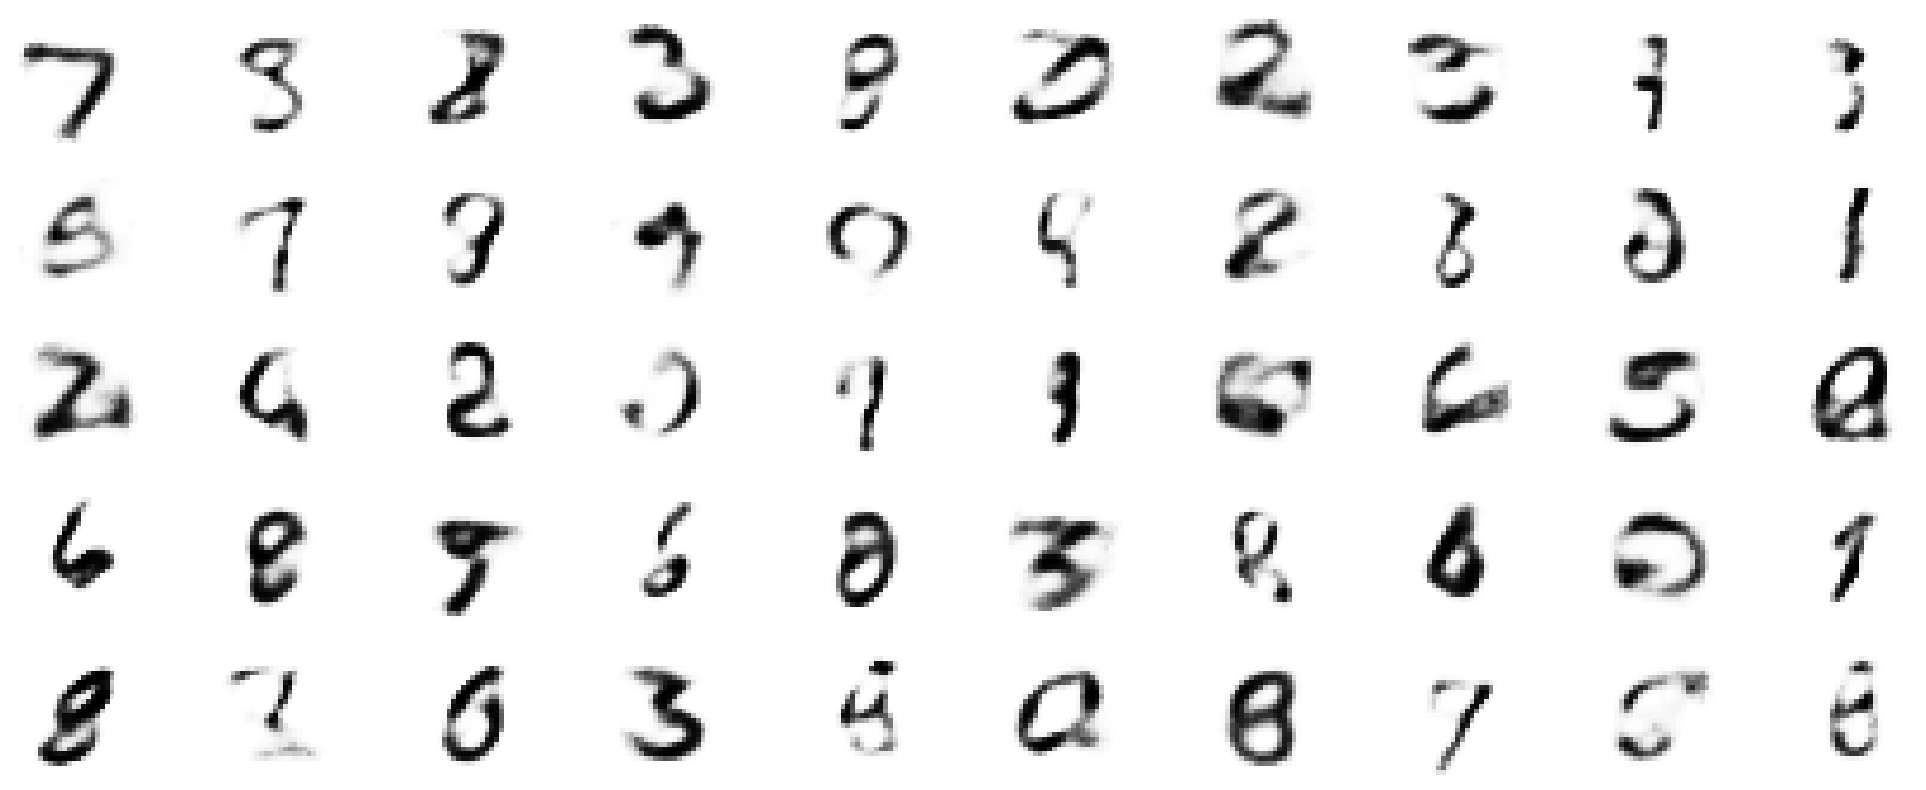

In [45]:
samples = 50

x = vae.rsample(samples,None,True).cpu().reshape(-1,28,28)

fig,axes = plt.subplots(5,10,figsize=(25,10))
for i,ax in enumerate(chain(*axes)):
    ax.imshow(x[i],cmap="Greys")
    ax.axis("off")
plt.show()

#### $\beta$-VAE

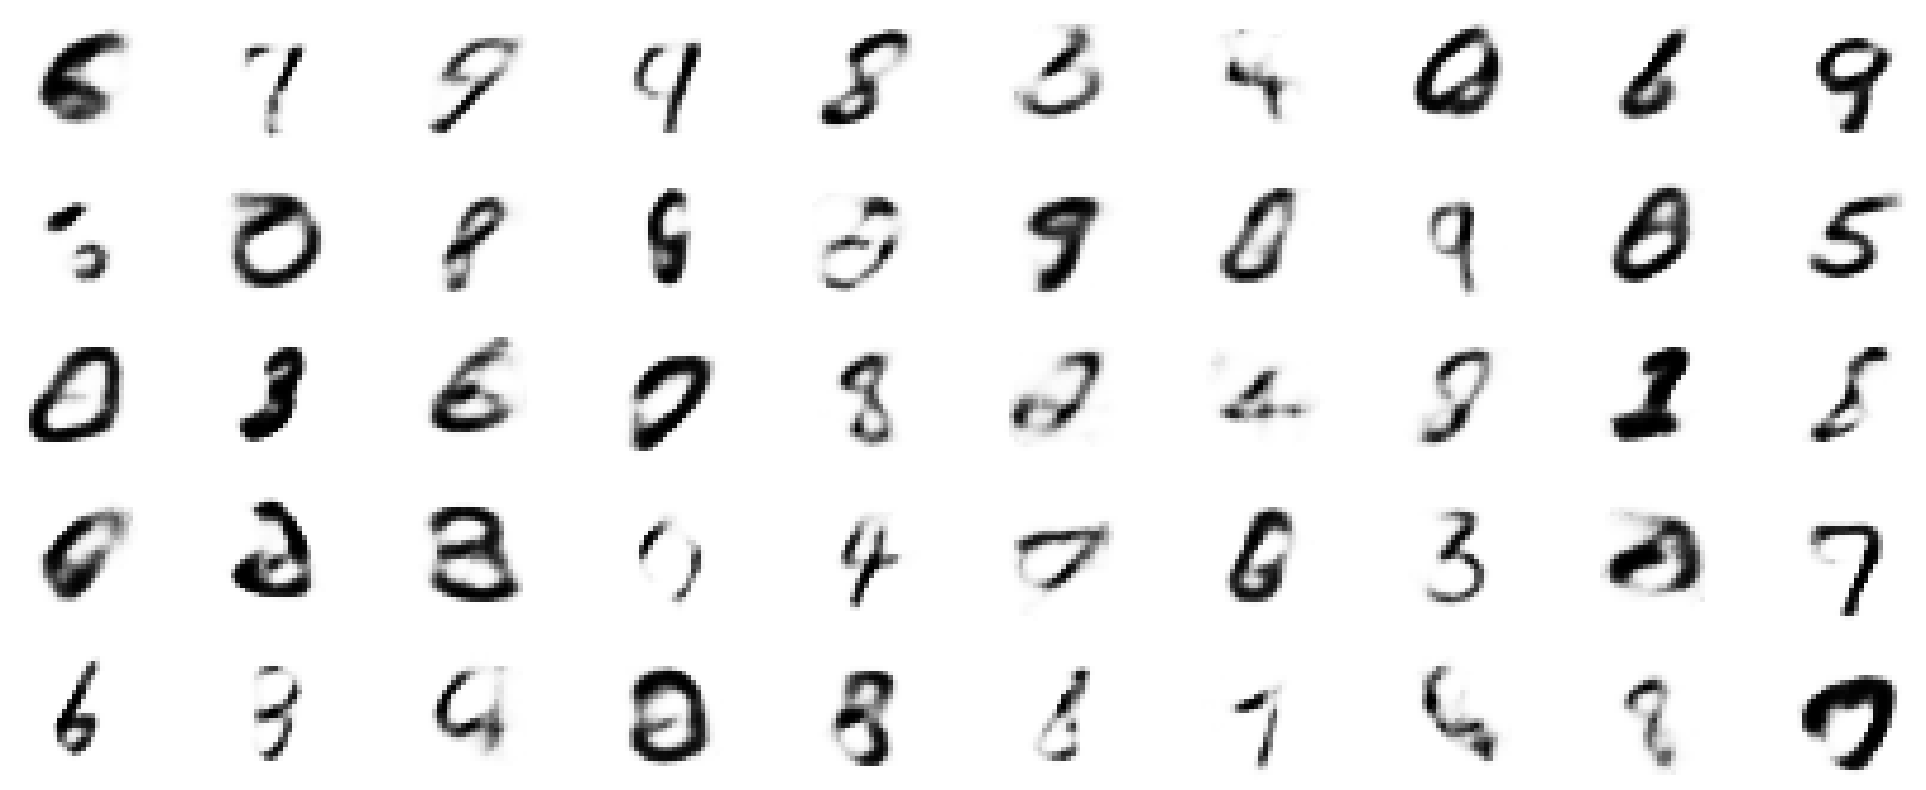

In [46]:
samples = 50

x = beta_vae.rsample(samples,None,True).cpu().reshape(-1,28,28)

fig,axes = plt.subplots(5,10,figsize=(25,10))
for i,ax in enumerate(chain(*axes)):
    ax.imshow(x[i],cmap="Greys")
    ax.axis("off")
plt.show()

#### CVAE

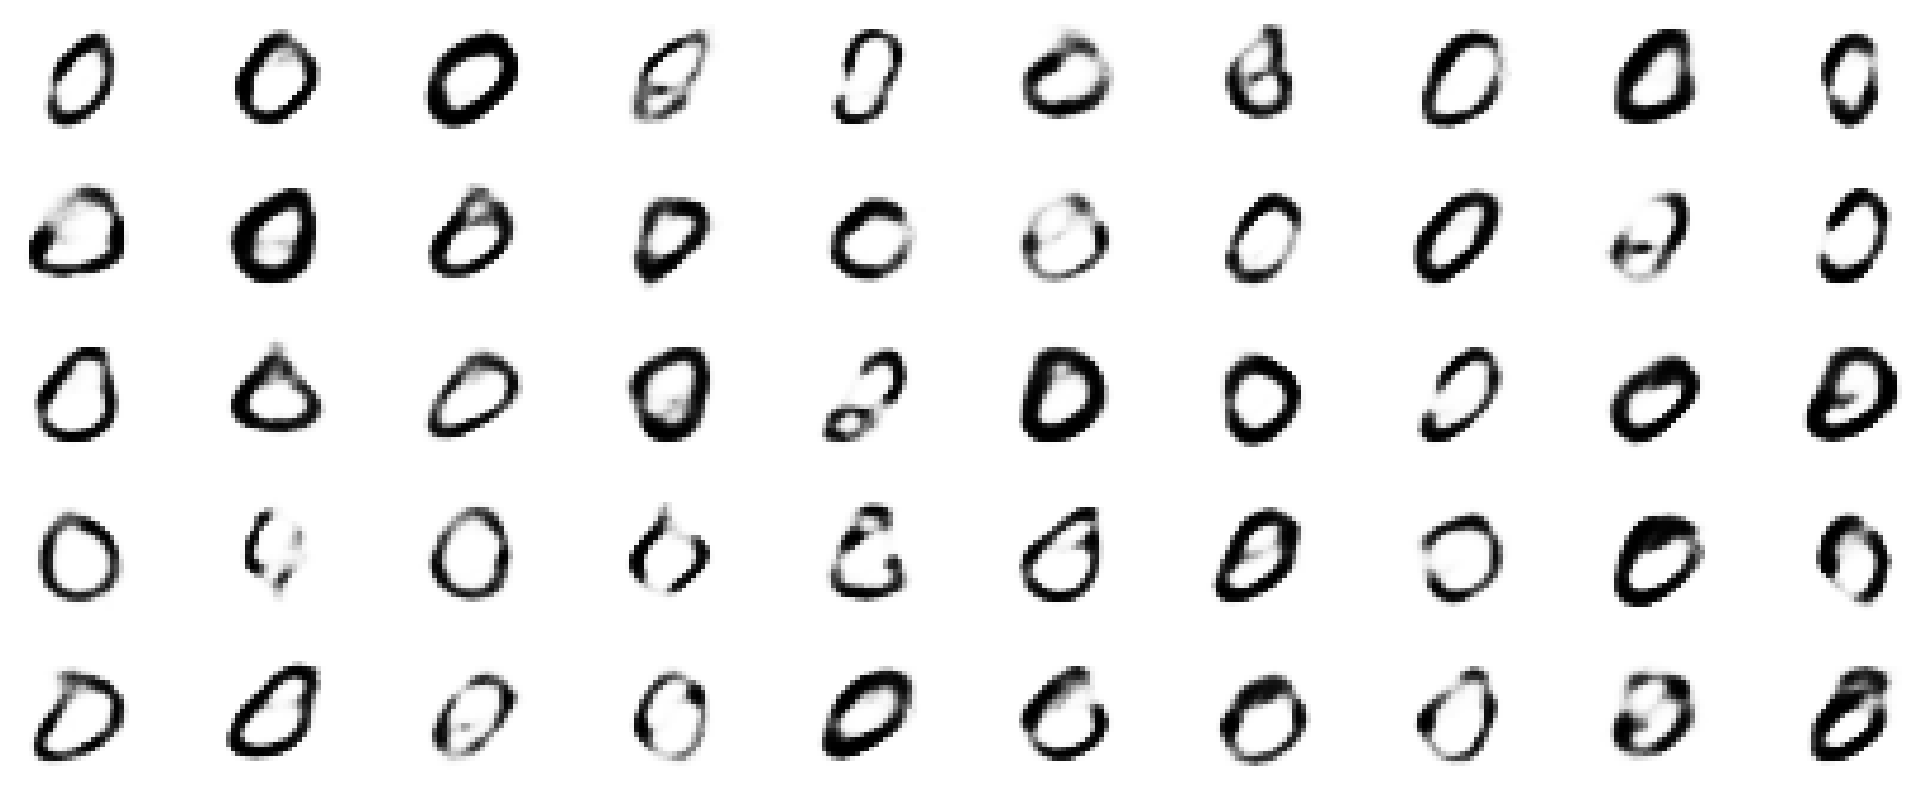

In [ ]:
label = 0 # conditional information
samples = 50

x = cond_vae.rsample(samples,label,True).cpu().reshape(-1,28,28)

fig,axes = plt.subplots(5,10,figsize=(25,10))
for i,ax in enumerate(chain(*axes)):
    ax.imshow(x[i],cmap="Greys")
    ax.axis("off")
plt.show()

### Interpolation

As these models create a continuous mapping from and to the latent space, we can encode two distinct images and create a path in the latent space between them. Then, if we map such path into the original space, we will obtain an interpolation between such pair of original images. The simplest method is the **linear interpolation**, which for some points $a,b\in\mathbb{R}^n$ it can be represented as the mapping $I:[0,1]\rightarrow \mathbb{R}^n$ given by

$$I(t) = (1-t)a+tb$$

In [62]:
def interpolation(images):
    n_steps = len(images)
    fig,ax = plt.subplots(1,n_steps,figsize=(5*n_steps,5))
    for i in range(n_steps):
        ax[i].imshow(
                images[i],
                cmap="Greys"
        )
        ax[i].axis("off")
    plt.show()

In [85]:
def autoencoder_interpolation(model:VAE, n_steps, img1, img2, label1=None, label2=None):
    t = 1+(torch.linspace(0,1,n_steps,device="cuda").reshape(-1,1)-1)**3
    t = torch.linspace(0,1,n_steps,device="cuda").reshape(-1,1)
    if model.one_hot_encode:
        label1 = torch.tensor(label1, device=model.device)
        label2 = torch.tensor(label2, device=model.device)
    with torch.no_grad():
        z1, _ = model.encode(img1.flatten().cuda(), label1)
        z2, _ = model.encode(img2.flatten().cuda(), label2)
        Z = z2*t + (1-t)*z1
        if label1 is not None and label2 is not None:
            label1 = torch.nn.functional.one_hot(label1.unsqueeze(0),10)
            label2 = torch.nn.functional.one_hot(label2.unsqueeze(0),10)
            L = label2*t + (1-t)*label1
            X = model.decoder(torch.cat([Z,L],dim=-1)).reshape(-1,28,28).cpu()
        else:
            X = model.decode(Z).reshape(-1,28,28).cpu()
        interpolation(X)

Now, lets select two random test images and show their interpolation with each model.

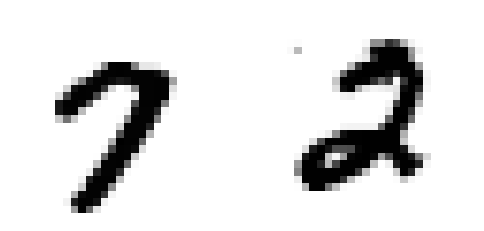

In [104]:
img1, lab1 = test_dataset.__getitem__(np.random.randint(0,len(test_dataset)))
img2, lab2 = test_dataset.__getitem__(np.random.randint(0,len(test_dataset)))

fig,ax = plt.subplots(1,2,figsize=(6,3))
ax[0].imshow(
    img1.reshape(28,28),
    cmap="Greys"
)
ax[0].axis("off")
ax[1].imshow(
    img2.reshape(28,28),
    cmap="Greys"
)
ax[1].axis("off")
plt.show()

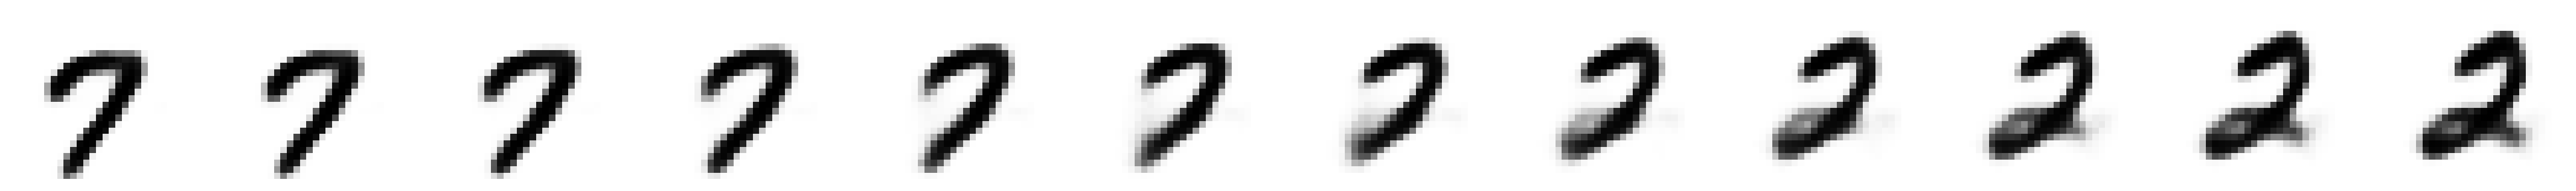

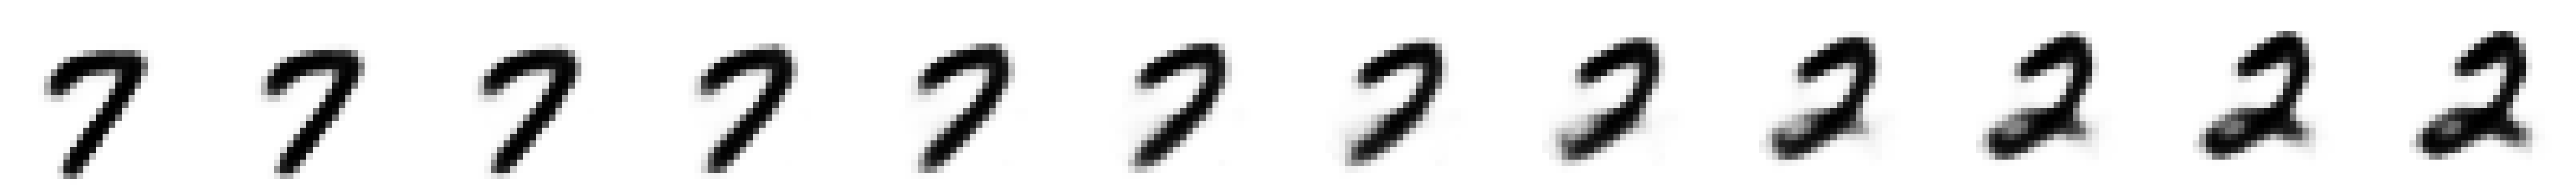

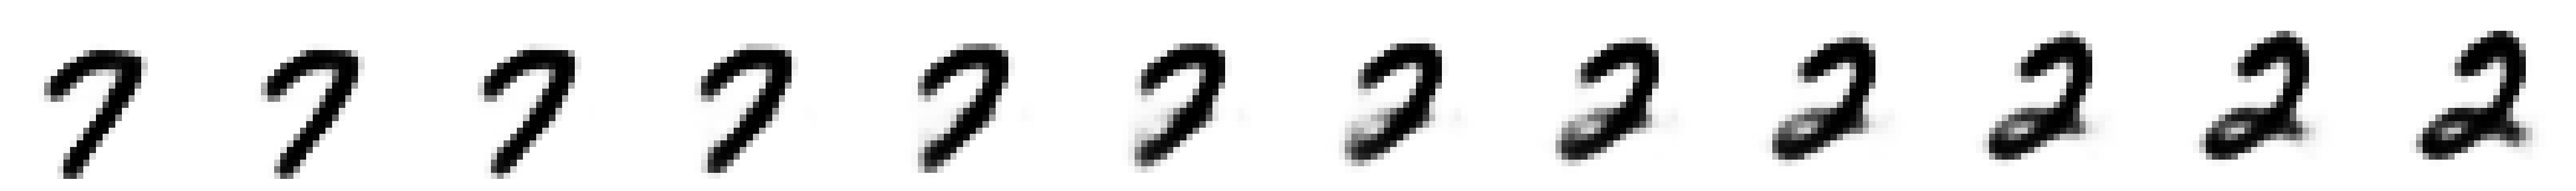

In [105]:
autoencoder_interpolation(vae, 12, img1, img2)

autoencoder_interpolation(beta_vae, 12, img1, img2)

autoencoder_interpolation(cond_vae, 12, img1, img2, lab1, lab2)

All three models appear to interpolate between the two points very smoothly. A more complex dataset would likely highlight the differences between these models more clearly.